In [1]:
import numpy as np
import pandas as pd
from sklearn import svm
from sklearn import model_selection
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import StratifiedKFold

In [2]:
df_test=pd.read_csv("../../../enhanced40_plusOpacity_features_3_classes/test_features_top40_anova.csv", sep=",")
df_validation=pd.read_csv("../../../enhanced40_plusOpacity_features_3_classes/validation_features_top40_anova.csv", sep=",")
df_train=pd.read_csv("../../../enhanced40_plusOpacity_features_3_classes/train_features_top40_anova.csv", sep=",")


In [3]:
X_train = df_train.drop(['filename','classe'], axis = 1)
y_train = df_train['classe']

X_test = df_test.drop(['filename','classe'], axis = 1)
y_test = df_test['classe']

X_val=df_validation.drop(['filename','classe'], axis = 1)
y_val=df_validation['classe']

df_train.head()

,filename,classe,coherence_tensor_lisse_droite_masque,coherence_tensor_lisse_masque,coherence_tensor_lisse_haut_masque,coherence_tensor_lisse_gauche_masque,coherence_tensor_lisse_bas_masque,coherence_tensor_lisse_bas_droit,coherence_structure_tensor_haut_gauche,coherence_tensor_lisse_bas_masque_sigma1,...,variance_laplacien_haut_gauche,rapport_fft_hautes_frequences_haut_bas,asymetrie_coherence_tensor_lisse_bas_gauche_droite,somme_sobel_horizontal_haut_droit,somme_sobel_horizontal_bas_droit,entropie_droite,asymetrie_flou_gauche_droite,variance_laplacien_bas_gauche,asymetrie_laplacien_bas_gauche_droit,somme_abs_laplacien_grand_noyau_bas_gauche
0,COVID-1.png,COVID,0.5787,0.5813,0.5605,0.5833,0.6016,0.5901,0.4404,0.7113,...,1974.7844,0.9991,0.0185,57116.0,-63120.0,7.7478,0.0711,1653.7820,0.0282,5542704.0
1,COVID-1000.png,COVID,0.6331,0.6214,0.6083,0.6120,0.6354,0.6526,0.3831,0.7364,...,2402.1373,0.6939,0.0221,54072.0,-50016.0,7.8581,0.0585,1415.6239,0.1318,5646624.0
2,COVID-1001.png,COVID,0.5800,0.5834,0.5810,0.5860,0.5859,0.5951,0.4927,0.6892,...,1704.5057,0.7840,0.0120,43149.0,-44593.0,7.8500,0.1056,2457.8949,0.2402,6181358.0
3,COVID-1003.png,COVID,0.6146,0.6262,0.6572,0.6358,0.5929,0.5650,0.1893,0.6889,...,2684.7613,0.8150,0.0403,82016.0,-82412.0,7.8866,0.0086,2192.3598,0.1339,9522280.0
4,COVID-1004.png,COVID,0.5799,0.5791,0.5645,0.5782,0.5933,0.5908,0.3769,0.6998,...,1186.0644,1.3104,0.0043,76772.0,-80192.0,7.8308,0.0457,964.1715,0.1740,4150580.0


In [4]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
X_val_scaled=scaler.transform(X_val)


In [5]:
covid_f1_scorer = make_scorer(f1_score, labels=["COVID"], average="macro")
parametres = {'C':[0.1,1,10], 'kernel':['rbf','linear', 'poly'], 'gamma':[0.001, 0.1, 0.5]}
clf = svm.SVC(class_weight='balanced')
grid_clf = model_selection.GridSearchCV(
    estimator=clf,
    param_grid=parametres,
    scoring=covid_f1_scorer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    refit=True
)
grille = grid_clf.fit(X_train_scaled, y_train)

In [ ]:
print(grid_clf.best_params_)

{'C': 0.1, 'gamma': 0.1, 'kernel': 'poly'}


In [12]:
from sklearn import metrics

def evaluer(model, X, y, titre):
    """Affiche accuracy, classification_report et matrice de confusion."""
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)

    print(f"===== {titre} =====")
    print(f"Accuracy : {acc:.4f}\n")
    print(classification_report(y, y_pred, zero_division=0))

    cm = confusion_matrix(y, y_pred,normalize='true')
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels=["COVID","OPACITY+V.PNEUMO.","NORMAL"] )
    cm_display.plot()
    plt.tight_layout()
    plt.show()
    return acc

===== SVM — Validation =====
Accuracy : 0.8243

                              precision    recall  f1-score   support

                       COVID       0.61      0.71      0.66       338
Lung_Opacity_Viral_Pneumonia       0.87      0.77      0.82       732
                      Normal       0.87      0.90      0.89      1013

                    accuracy                           0.82      2083
                   macro avg       0.79      0.79      0.79      2083
                weighted avg       0.83      0.82      0.83      2083



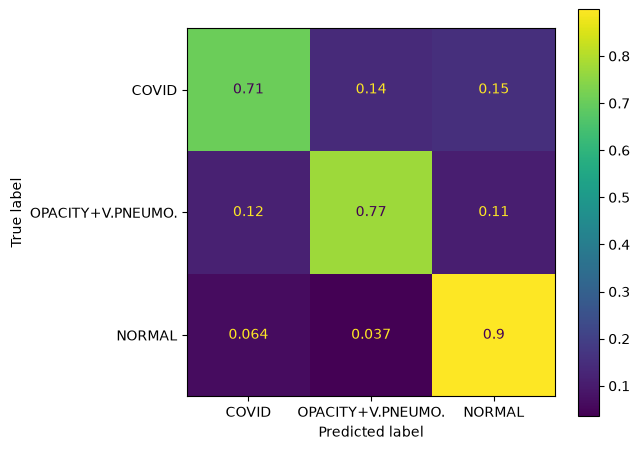

===== SVM — Test =====
Accuracy : 0.8301

                              precision    recall  f1-score   support

                       COVID       0.63      0.74      0.68       337
Lung_Opacity_Viral_Pneumonia       0.88      0.78      0.83       733
                      Normal       0.88      0.90      0.89      1014

                    accuracy                           0.83      2084
                   macro avg       0.79      0.81      0.80      2084
                weighted avg       0.84      0.83      0.83      2084



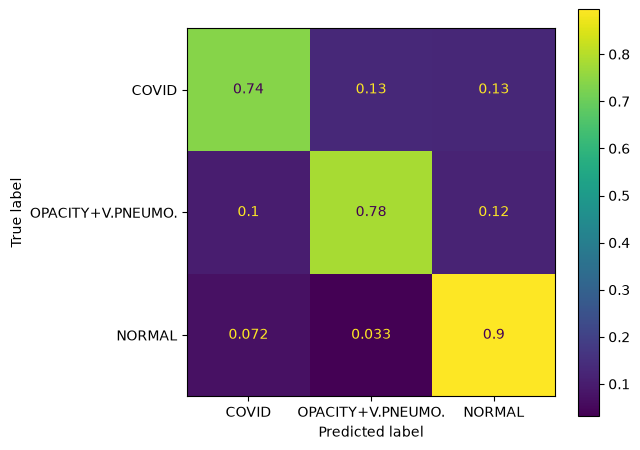

In [13]:

acc_val  = evaluer(grid_clf, X_val_scaled,  y_val,  "SVM — Validation")
acc_test = evaluer(grid_clf, X_test_scaled, y_test, "SVM — Test")